# D02 · Imperfect data: missing values, measurement error and outliers as parts of the model

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Palmer Station penguins **as recorded in the field** (344 birds; body measurements, sex and blood isotopes, with holes) · divorce and marriage rates of the 50 US states **with their published standard errors** |
| **You will learn** | Missing-data triage and what MCAR / MAR / MNAR license · PyMC's automatic imputation (`observed=` with `NaN`) and what it really creates · why a missing **covariate** needs a model and what deletion and mean-filling assume instead · marginalising a missing **discrete** covariate by hand and with `pymc_extras.marginalize` · a selection model for values that are missing *because of* what they are · measurement error in the outcome and in a predictor, shrinkage and attenuation · influential points with PSIS-LOO, Student-t likelihoods, outlier versus data error · rounding as a likelihood (`pm.CustomDist`) |

The thesis of this notebook fits in one sentence: **the Bayesian answer to a data problem
is almost never a preprocessing step - it is another line in the model.**

Deleting incomplete rows, filling holes with the column mean, trimming "outliers" and
treating a published estimate as if it were the truth all feel like neutral housekeeping.
None of them is. Each one is a *modelling assumption* made silently, in pandas, where no
diagnostic can reach it:

| Housekeeping step | The assumption it makes |
|---|---|
| drop rows with a `NaN` | the rows that remain are a random sample of all rows |
| fill with the mean | the missing value is known exactly, and equals the mean |
| use a published rate as data | the rate was measured without error |
| delete the outlier | that point was generated by a process you need not describe |

Writing the assumption *into the model* costs a few lines. In return it becomes visible,
checkable, and its uncertainty flows into every downstream number. **D01** covers cleaning
and encoding; this notebook starts where cleaning stops - with the holes and the noise that
no amount of cleaning removes.

In [1]:
import logging
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pymc.exceptions import ImputationWarning
from pymc_extras.marginal import marginalize, recover
from scipy import stats
from scipy.special import expit

from pymc_challenges import data

RANDOM_SEED = 2718
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.ERROR)  # ~35 small fits below: keep the sampler log quiet

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Question and data

Gorman, Williams and Fraser measured three penguin species near Palmer Station, Antarctica,
over three breeding seasons. Besides the familiar body measurements they took a blood sample
from each bird, used to determine its **sex** (by DNA) and two stable-isotope ratios. One of
them, $\delta^{15}$N, rises with **trophic position**: a bird that eats more fish and less
krill has a higher value.

*Within a species and sex, are birds that feed higher in the food web heavier or lighter?*
The regression is simple on purpose. The data problems are the subject.

A minimal inline clean (D01 does this properly, with range checks and assertions):

In [2]:
data.describe("penguins_raw")
raw = data.load("penguins_raw")

peng = pd.DataFrame({
    "species": raw["Species"].str.split().str[0],
    "year": pd.to_datetime(raw["Date Egg"]).dt.year,
    "mass": raw["Body Mass (g)"] / 1000,                      # kg
    "bill_depth": raw["Culmen Depth (mm)"],
    "male": raw["Sex"].map({"FEMALE": 0.0, "MALE": 1.0}),      # NaN stays NaN
    "d15n": raw["Delta 15 N (o/oo)"],
    "comment": raw["Comments"],
}).reset_index(drop=True)

SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
YEARS = [2007, 2008, 2009]
X_REF = 8.7  # centre d15N here (close to its overall mean), so intercepts mean something

peng.head()

penguins_raw: 344 penguins as recorded in the field: messy column names, dates, comments, missing measurements.
  source: Gorman, Williams & Fraser (2014), Palmer Station LTER, via R `palmerpenguins` (raw field records).
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/palmerpenguins/penguins_raw.csv


,species,year,mass,bill_depth,male,d15n,comment
0,Adelie,2007,3.75,18.7,1.0,NaN,Not enough blood for isotopes.
1,Adelie,2007,3.80,17.4,0.0,8.94956,NaN
2,Adelie,2007,3.25,18.0,0.0,8.36821,NaN
3,Adelie,2007,NaN,NaN,NaN,NaN,Adult not sampled.
4,Adelie,2007,3.45,19.3,0.0,8.76651,NaN


## 2 · Triage: how much is missing, where, and why?

Three questions before any modelling: **how much**, **in which variables and rows**, and
**is the missingness related to anything we did observe?**

            n missing    %
mass                2  0.6
bill_depth          2  0.6
male               11  3.2
d15n               14  4.1

rows with at least one hole: 20 of 344


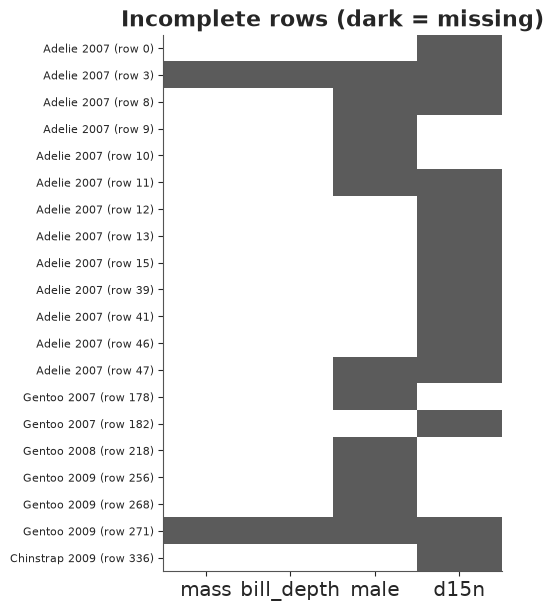

In [3]:
cols = ["mass", "bill_depth", "male", "d15n"]
missing = peng[cols].isna()
print(pd.DataFrame({"n missing": missing.sum(), "%": (100 * missing.mean()).round(1)}))
print(f"\nrows with at least one hole: {missing.any(axis=1).sum()} of {len(peng)}")

incomplete = peng[missing.any(axis=1)]
fig, ax = plt.subplots(figsize=(5, 6))
ax.imshow(incomplete[cols].isna(), aspect="auto", cmap="Greys", vmin=0, vmax=1.4)
ax.set_xticks(range(len(cols)), cols)
ax.set_yticks(range(len(incomplete)), [f"{r.species} {r.year} (row {i})" for i, r in incomplete.iterrows()],
              fontsize=8)
ax.set_title("Incomplete rows (dark = missing)");

Few holes, but they are **structured**: two birds have nothing at all, the isotope holes
are nearly all Adelies from 2007, and sex is missing for a different set of birds than
$\delta^{15}$N. A complete-case analysis drops all 20 rows. Field data often says *why* a
value is missing, and that is worth more than any statistical test:

In [4]:
print(incomplete.comment.value_counts().to_string())
print()
print(peng.assign(no_d15n=peng.d15n.isna()).groupby("year").no_d15n.agg(["sum", "size"])
      .rename(columns={"sum": "d15n missing", "size": "birds"}))

comment
Not enough blood for isotopes.                                          7
Sexing primers did not amplify.                                         4
No blood sample obtained.                                               2
No blood sample obtained for sexing.                                    2
Adult not sampled.                                                      1
Nest never observed with full clutch. Not enough blood for isotopes.    1
Sexing primers did not amplify. Not enough blood for isotopes.          1
Adult not sampled. Nest never observed with full clutch.                1
No delta15N data received from lab.                                     1

      d15n missing  birds
year                     
2007            12    110
2008             0    114
2009             2    120


"Not enough blood for isotopes", "sexing primers did not amplify", "adult not sampled":
logistics and lab chemistry. Most isotope holes come from the **first field season**.

A plausible worry: a smaller bird yields less blood, so the *outcome* (mass) could drive the
missingness of the covariate. That is a checkable statement - **model the missingness
indicator** like any other binary outcome. Predictors: first season or not, and body mass
standardised within species.

In [5]:
measured = peng.dropna(subset=["mass"]).reset_index(drop=True)   # the 2 empty rows cannot enter
d15n_missing = measured.d15n.isna().to_numpy().astype(int)
first_season = (measured.year == 2007).to_numpy().astype(float)
mass_z = measured.groupby("species").mass.transform(lambda s: (s - s.mean()) / s.std()).to_numpy()

with pm.Model() as triage_model:
    c0 = pm.Normal("intercept", -3, 2)            # missingness is rare: centre the prior near 5%
    c_first = pm.Normal("first_season", 0, 1.5)   # log-odds ratios beyond +-3 would be extreme
    c_mass = pm.Normal("mass_z", 0, 1.5)
    pm.Bernoulli("d15n_missing", logit_p=c0 + c_first * first_season + c_mass * mass_z,
                 observed=d15n_missing)
    triage_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

az.summary(triage_idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,-4.72,0.60,-5.84,-3.67,1254.75,1344.74,1.0,0.02,0.01
first_season,2.34,0.66,1.15,3.63,1220.62,1315.39,1.0,0.02,0.01
mass_z,0.01,0.29,-0.53,0.59,2352.07,2365.29,1.0,0.01,0.00


The first season raises the odds of a missing isotope value roughly tenfold
($e^{2.4} \approx 11$), while the coefficient of body mass is centred on zero - though with
only 12 events its interval is wide, so "no evidence of" is all we can say. Missingness that
depends on *season* matters only if $\delta^{15}$N itself differs between seasons:

In [6]:
peng.groupby(["species", "year"]).d15n.mean().unstack().round(2)

year,2007,2008,2009
species,,,
Adelie,9.02,8.56,9.02
Chinstrap,9.12,9.44,9.56
Gentoo,7.97,8.42,8.27


It does, by up to half a unit - as much as the spread *within* a species and season. So any
model for the missing values must know the **season**. That is the output of triage: not a verdict,
but a list of variables the missing-data model has to condition on.

### MCAR, MAR, MNAR - and what each one licenses

Write $R$ for the missingness indicator, $Y_\text{obs}$ for everything observed, $Y_\text{mis}$
for the values we do not have.

- **MCAR** (missing completely at random): $R$ is independent of everything, observed or
  not - a dropped test tube. The complete cases are a random subsample, so deleting rows is
  *unbiased*; it only wastes data. MCAR can be refuted from the data (we just did: season
  predicts $R$) but never confirmed.
- **MAR** (missing at random): $R$ depends only on things we **observed** - here season and
  perhaps mass. Given a model that conditions on those things, the missingness mechanism
  drops out of the likelihood ("ignorability") and the missing values are just more
  unknowns to integrate over. Deleting rows can now be biased - in a regression, whenever
  $R$ depends on the **outcome** - while a joint model is not.
- **MNAR** (missing not at random): $R$ depends on the missing value **itself**, even after
  conditioning on everything observed - the lab returns nothing above a detection range,
  heavy drinkers skip the alcohol question. The mechanism no longer drops out: you must model
  $R$ jointly with the data, and what identifies that model is an assumption that the data
  cannot check. MAR versus MNAR is **never testable** from the data at hand; it is argued
  from how the data were collected. "No blood sample obtained" is an argument for MAR.

## 3 · Missing outcomes: PyMC's automatic imputation

The easy case first. Two birds have no body mass. Hand PyMC an `observed=` array that
contains `NaN` (a NumPy array, a masked array or a pandas Series all behave the same) and it
splits the variable in two:

In [7]:
sp_all = pd.Categorical(peng.species, SPECIES).codes

with pm.Model(coords={"species": SPECIES, "bird": peng.index}) as outcome_model:
    a = pm.Normal("a", 4, 1, dims="species")
    sigma = pm.HalfNormal("sigma", 0.5)
    pm.Normal("mass", a[sp_all], sigma, observed=peng.mass, dims="bird")   # 2 NaN inside

print("free RVs      :", [v.name for v in outcome_model.free_RVs])
print("observed RVs  :", [v.name for v in outcome_model.observed_RVs])
print("deterministics:", [v.name for v in outcome_model.deterministics])
print("dims          :", outcome_model.named_vars_to_dims)

free RVs      : ['a', 'sigma', 'mass_unobserved']
observed RVs  : ['mass_observed']
deterministics: ['mass']
dims          : {'a': ('species',), 'mass': ('bird',)}


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in mass contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Read that output carefully, because it is all there is to "automatic imputation" in PyMC
6:

- an `ImputationWarning` tells you it happened (from here on we silence it);
- **`mass_observed`** is the likelihood of the 342 measured values;
- **`mass_unobserved`** is a new *free random variable* with the same distribution, one
  element per `NaN`. It is sampled by NUTS like any parameter - and since it is continuous,
  the default nutpie sampler is perfectly happy;
- **`mass`**, the name you chose, is now a `Deterministic` that stitches the two back together
  in the original row order. It is the only one that keeps your `dims`; the two halves get
  anonymous dimensions such as `mass_unobserved_dim_0`. Use `mass` downstream.

Two limitations: `pm.Data` refuses `NaN`, so an imputed variable cannot be swapped with
`pm.set_data`; and the pointwise log-likelihood (hence LOO) covers `mass_observed` only.

In [8]:
warnings.filterwarnings("ignore", category=ImputationWarning)

try:
    with pm.Model():
        pm.Data("mass", peng.mass.to_numpy())
except NotImplementedError as err:
    print("pm.Data with NaN ->", err)

with outcome_model:
    outcome_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

# the same model on the 342 complete rows
with pm.Model(coords={"species": SPECIES}) as dropped_model:
    a = pm.Normal("a", 4, 1, dims="species")
    sigma = pm.HalfNormal("sigma", 0.5)
    pm.Normal("mass", a[sp_all[peng.mass.notna()]], sigma, observed=peng.mass.dropna())
    dropped_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

pd.concat({
    "NaN in observed (344 rows)": az.summary(outcome_idata, var_names=["a", "sigma", "mass_unobserved"],
                                             round_to=3)[["mean", "sd", "r_hat"]],
    "rows dropped (342 rows)": az.summary(dropped_idata, var_names=["a", "sigma"], round_to=3)[["mean", "sd", "r_hat"]],
}, axis=1)

pm.Data with NaN -> Masked arrays or arrays with `nan` entries are not supported. Pass them directly to `observed` if you want to trigger auto-imputation


NaN in observed (344 rows)                \
                                         mean     sd  r_hat   
a[Adelie]                               3.701  0.037  1.001   
a[Chinstrap]                            3.733  0.057  1.001   
a[Gentoo]                               5.074  0.042  1.001   
sigma                                   0.463  0.017  1.001   
mass_unobserved[0]                      3.706  0.464  1.000   
mass_unobserved[1]                      5.073  0.467  1.000   

                   rows dropped (342 rows)                
                                      mean     sd  r_hat  
a[Adelie]                            3.701  0.037  1.000  
a[Chinstrap]                         3.734  0.055  1.002  
a[Gentoo]                            5.074  0.042  1.001  
sigma                                0.463  0.018  1.004  
mass_unobserved[0]                     NaN    NaN    NaN  
mass_unobserved[1]                     NaN    NaN    NaN

The parameters are the same to within Monte Carlo error, and they must be. A missing
**outcome** under MAR contributes the factor $\int p(y_\text{mis} \mid \theta)\,dy_\text{mis} = 1$
to the likelihood: it **carries no information about the parameters**. `mass_unobserved` is
simply the posterior predictive distribution for those two birds (an Adelie and a Gentoo:
compare their means with `a`, and their sd with `sigma`). Imputing outcomes is a
convenience for prediction and bookkeeping. It never rescues an analysis.

The same is not true of a missing *covariate*.

## 4 · A missing continuous covariate needs a model

The analysis model, for bird $i$ of species $s$ measured in season $t$:

$$
\text{mass}_i \sim \text{Normal}\big(\alpha_{s[i],\,t[i]} + \beta_\text{male}\,\text{male}_i
    + \beta_N\,(\delta^{15}\text{N}_i - 8.7),\ \sigma\big)
$$

The intercept varies by species **and season** for a substantive reason that triage just
handed us: the isotopic baseline of the food web shifts from year to year, so a difference in
$\delta^{15}$N *between* seasons is not a difference in trophic position. $\beta_N$ should be
a within-season comparison.

When $\delta^{15}$N$_i$ is missing, this likelihood term cannot be evaluated. Unlike a missing
outcome it does not integrate to one: the row still holds a measured mass, which is
informative about $\beta_N$ *if* we can say which values of $\delta^{15}$N are plausible
for that bird. That statement is a **model for the covariate**, and triage told us what
belongs in it - species, season and (looking at the group means) sex:

$$
\delta^{15}\text{N}_i \sim \text{Normal}\big(\mu_{s[i],\,t[i]} + \gamma\,\text{male}_i,\ \tau_{s[i]}\big)
$$

In PyMC this is one extra line: give $\delta^{15}$N a distribution, pass the column with its
`NaN`s as `observed=`, and use the resulting variable in the regression. Each missing value
becomes a parameter whose posterior combines the covariate model (*what do Adelies in 2007
look like?*) with the outcome (*what does this bird's mass suggest?*).

Priors: intercepts `Normal(4, 1)` kg cover every penguin in the study; `Normal(0, 0.5)` kg per
unit of $\delta^{15}$N is generous, since the isotope spans about two units and mass varies
by a few hundred grams within a group. The helpers below are reused for the rest of part 1.

In [9]:
def design(d):
    """Index vectors for a penguin table: species code, season code, male indicator."""
    return (pd.Categorical(d.species, SPECIES).codes, pd.Categorical(d.year, YEARS).codes,
            d.male.to_numpy())


def penguin_priors():
    """Priors shared by every model of part 1 (call inside a model context)."""
    return {
        "mu_x": pm.Normal("mu_x", X_REF, 1.0, dims=("species", "year")),   # mean d15N, females
        "g_x": pm.Normal("g_x", 0, 0.5),                                   # male - female, d15N
        "s_x": pm.HalfNormal("s_x", 0.5, dims="species"),
        "a": pm.Normal("a", 4, 1, dims=("species", "year")),               # kg, female at d15N = 8.7
        "b_male": pm.Normal("b_male", 0, 1),
        "b_n": pm.Normal("b_n", 0, 0.5),                                   # kg per unit d15N
        "sigma": pm.HalfNormal("sigma", 0.5),
    }


def sexed_likelihood(p, d, d15n, suffix=""):
    """Covariate model + analysis model for birds of known sex. `d15n` may contain NaN."""
    sp, yr, male = design(d)
    x = pm.Normal("d15n" + suffix, p["mu_x"][sp, yr] + p["g_x"] * male, p["s_x"][sp], observed=np.asarray(d15n))
    pm.Normal("mass" + suffix, p["a"][sp, yr] + p["b_male"] * male + p["b_n"] * (x - X_REF), p["sigma"],
              observed=d.mass.to_numpy())
    return x


def fit_mass(d, d15n, selection=False, var_names=None, prior_only=False):
    """Fit the joint model to table `d` using the d15N column `d15n` (NaN = impute)."""
    with pm.Model(coords={"species": SPECIES, "year": YEARS}) as model:
        x = sexed_likelihood(penguin_priors(), d, d15n)
        if selection:  # section 6: model the missingness indicator as a function of the value itself
            c0 = pm.Normal("c0", 0, 2)
            c1 = pm.Normal("c1", 0, 3)
            pm.Bernoulli("is_missing", logit_p=c0 + c1 * (x - X_REF), observed=np.isnan(d15n).astype(int))
        if prior_only:
            return model, pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=var_names)
    return model, idata


STITCHED = {"mass", "d15n", "d15n_sexed"}   # observed + imputed, stitched together: mostly constants


def check(idata, label):
    """One-line sampler report: divergences, worst r_hat, smallest bulk ESS."""
    names = [v for v in idata.posterior.data_vars if v not in STITCHED]
    rhat = max(float(v.max()) for v in az.rhat(idata, var_names=names).data_vars.values())
    ess = min(float(v.min()) for v in az.ess(idata, var_names=names).data_vars.values())
    print(f"{label:<34} divergences {int(idata.sample_stats['diverging'].sum()):>2}   "
          f"max r_hat {rhat:.3f}   min ess_bulk {ess:,.0f}")


sexed = peng.dropna(subset=["mass", "male"]).reset_index(drop=True)
print(f"birds with mass and sex: {len(sexed)}, of which d15N missing: {sexed.d15n.isna().sum()}")

_, mass_prior = fit_mass(sexed, sexed.d15n.to_numpy(), prior_only=True)
prior_mass = mass_prior.prior_predictive["mass"]
print("prior predictive body mass, 3% / 50% / 97% quantiles (kg):",
      np.quantile(prior_mass, [0.03, 0.5, 0.97]).round(1))

birds with mass and sex: 333, of which d15N missing: 9
prior predictive body mass, 3% / 50% / 97% quantiles (kg): [1.2 3.9 6.7]


The prior predictive puts 94% of birds between roughly 1 and 7 kg: wider than the real range
(2.7-6.3 kg), but penguin-sized. Now three ways
to treat the missing isotope values, **same model code each time**:

- **complete cases**: drop the rows;
- **mean-fill**: replace each `NaN` with the column mean (`df.fillna(df.mean())`);
- **joint model**: leave the `NaN`s in and let the covariate model impute.

(With no `NaN` present the covariate model and the regression share no parameters, so the
extra line is harmless: the posterior of the regression is what it would be without it.)

In [10]:
complete = sexed.dropna(subset=["d15n"]).reset_index(drop=True)

real_fits = {
    "complete cases": fit_mass(complete, complete.d15n.to_numpy()),
    "mean-fill": fit_mass(sexed, sexed.d15n.fillna(sexed.d15n.mean()).to_numpy()),
    "joint model": fit_mass(sexed, sexed.d15n.to_numpy()),
}
for label, (_, idata) in real_fits.items():
    check(idata, f"{label} ({'324' if label == 'complete cases' else '333'} rows)")

full_model, full_idata = real_fits["complete cases"]   # reused below as the "truth" of the experiments


def coef_table(fits, var_names=("b_n", "b_male", "sigma")):
    """Posterior mean and sd of a few scalars for a dict of label -> idata."""
    out = {}
    for label, idata in fits.items():
        post = az.extract(idata, var_names=list(var_names))
        out[label] = {f"{v} {stat}": getattr(post[v], stat)().item() for v in var_names for stat in ("mean", "std")}
    return pd.DataFrame(out).T.round(3)


coef_table({k: v[1] for k, v in real_fits.items()})

complete cases (324 rows)          divergences  0   max r_hat 1.005   min ess_bulk 1,912
mean-fill (333 rows)               divergences  0   max r_hat 1.003   min ess_bulk 1,875
joint model (333 rows)             divergences  0   max r_hat 1.006   min ess_bulk 1,268


,b_n mean,b_n std,b_male mean,b_male std,sigma mean,sigma std
complete cases,-0.203,0.058,0.703,0.035,0.311,0.012
mean-fill,-0.181,0.057,0.690,0.035,0.313,0.012
joint model,-0.204,0.060,0.696,0.036,0.312,0.012


**All three agree** to well within one posterior sd, and it would be dishonest to pretend
otherwise: within a species, season and sex, a bird one unit higher in $\delta^{15}$N is
about 0.2 kg *lighter*, whichever way the 9 holes are handled. When under 3% of a covariate
is missing and the mechanism is benign, the method hardly matters. (Look closely, though:
complete cases and the joint model agree to the third decimal, while nine mean-filled values
were enough to pull the mean-fill estimate about 10% towards zero.) The joint model is still
the one whose assumptions are on the page.

A quick posterior predictive check of the joint model before we lean on it:

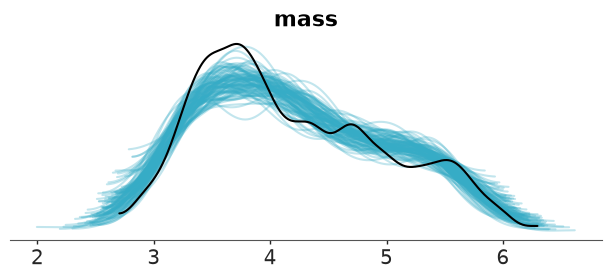

In [11]:
joint_model, joint_idata = real_fits["joint model"]
with joint_model:
    pm.sample_posterior_predictive(joint_idata, var_names=["mass"], extend_inferencedata=True,
                                   random_seed=RANDOM_SEED, progressbar=False)
az.plot_ppc_dist(joint_idata, var_names=["mass"], num_samples=100);

The broad shape with its heavy shoulder (Gentoos) is reproduced; the observed peak near 3.7 kg
is a little sharper than in most replicates. Good enough for our purpose.

### When it *does* matter: a controlled deletion experiment

To see the methods come apart we need more missingness and a less benign mechanism. Take the
324 complete birds - so that the full-data answer is known - and **delete** isotope values
with the mechanism we worried about in triage: *within its species and sex, a lighter bird
is more likely to give too little blood.*

$$P(\delta^{15}\text{N}_i \text{ missing}) = \text{logit}^{-1}(-0.3 - 1.5\, z_i),
\qquad z_i = \text{mass standardised within species and sex}$$

This is **MAR**: mass is always observed. But the thing driving the missingness is the
*outcome* of our regression.

In [12]:
z_within = complete.groupby(["species", "male"]).mass.transform(lambda s: (s - s.mean()) / s.std()).to_numpy()


def delete_mar(seed):
    """Boolean mask of deleted d15N values: lighter birds (within group) lose theirs more often."""
    return np.random.default_rng(seed).random(len(complete)) < expit(-0.3 - 1.5 * z_within)


deleted = delete_mar(RANDOM_SEED)
d15n_mar = complete.d15n.where(~deleted).to_numpy()
print(f"deleted {deleted.sum()} of {len(complete)} d15N values ({deleted.mean():.0%})")
print(f"mean mass: birds that kept their value {complete.mass[~deleted].mean():.2f} kg, "
      f"birds that lost it {complete.mass[deleted].mean():.2f} kg")

mar_fits = {
    "full data (the target)": full_idata,
    "complete cases": fit_mass(complete[~deleted].reset_index(drop=True), d15n_mar[~deleted])[1],
    "mean-fill": fit_mass(complete, np.where(deleted, np.nanmean(d15n_mar), d15n_mar))[1],
    "joint model": fit_mass(complete, d15n_mar)[1],
}
for label, idata in mar_fits.items():
    check(idata, label)
coef_table(mar_fits)

deleted 151 of 324 d15N values (47%)
mean mass: birds that kept their value 4.37 kg, birds that lost it 4.03 kg


full data (the target)             divergences  0   max r_hat 1.005   min ess_bulk 1,912
complete cases                     divergences  0   max r_hat 1.002   min ess_bulk 1,670
mean-fill                          divergences  0   max r_hat 1.005   min ess_bulk 3,377


joint model                        divergences  0   max r_hat 1.006   min ess_bulk 1,035


,b_n mean,b_n std,b_male mean,b_male std,sigma mean,sigma std
full data (the target),-0.203,0.058,0.703,0.035,0.311,0.012
complete cases,-0.169,0.082,0.730,0.047,0.289,0.017
mean-fill,-0.039,0.060,0.678,0.036,0.317,0.013
joint model,-0.192,0.088,0.705,0.039,0.312,0.013


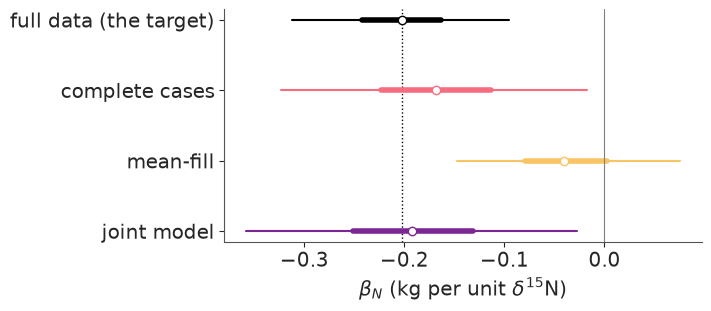

In [13]:
def interval_plot(ax, fits, var, truth_label=None, xlabel=None):
    """Posterior median with 50% and 94% intervals of scalar `var` for each fit."""
    for row, (label, idata) in enumerate(fits.items()):
        draws = az.extract(idata, var_names=var).values
        q = np.quantile(draws, [0.03, 0.25, 0.5, 0.75, 0.97])
        color = "k" if label == truth_label else f"C{row}"
        ax.plot(q[[0, 4]], [row, row], color=color, lw=1.5)
        ax.plot(q[[1, 3]], [row, row], color=color, lw=4)
        ax.plot(q[2], row, "o", color="w", mec=color, zorder=3)
        if label == truth_label:
            ax.axvline(q[2], color="k", ls=":", lw=1)
    ax.set_yticks(range(len(fits)), list(fits))
    ax.invert_yaxis()
    ax.set(xlabel=xlabel or var)


fig, ax = plt.subplots(figsize=(7, 3))
interval_plot(ax, mar_fits, "b_n", truth_label="full data (the target)", xlabel=r"$\beta_N$ (kg per unit $\delta^{15}$N)")
ax.axvline(0, color="grey", lw=0.8);

Read the table and the figure together (thick bar 50%, thin bar 94%, dotted line = the
full-data posterior median that every method is trying to reproduce):

- **Mean-fill** is the worst offender. The filled-in value is wrong for every bird - an
  Adelie female and a Chinstrap male get the same number - so the covariate is polluted with
  noise that is unrelated to mass, and the slope is dragged **towards zero**. Worse, its
  posterior sd is about the same as with the *full* data: the model was told that the
  invented values are measurements, so it claims precision it does not have.
- **Complete cases** is honest about its uncertainty but selected on the outcome: lighter
  birds are under-represented in every group, which flattens the slope.
- **The joint model** sits closest to the target, with the widest interval of the three -
  the correct price for not knowing almost half of the covariate.

One deletion pattern is one draw from a random mechanism, and the differences above are not
large compared with the posterior sd. Bias is a statement about the *average* over such
draws, so repeat the deletion a few times. To keep the runtime sane only the joint model is
refitted by MCMC; for the other two we use least squares, which with priors this weak is
within rounding of the posterior mean (compare the first row with the table above).

full-data estimate: -0.198
                mean over 8 deletions     sd
complete cases                 -0.160  0.054
mean-fill                      -0.038  0.042
joint model                    -0.216  0.064


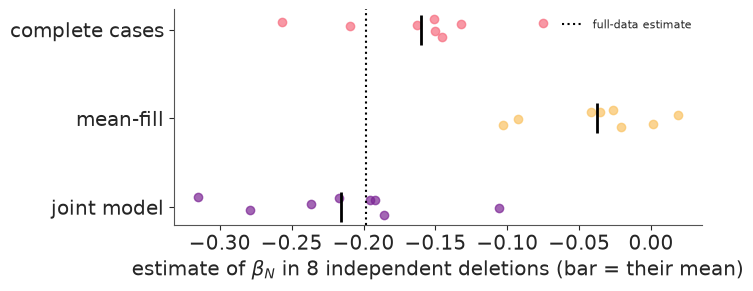

In [14]:
dummies = pd.get_dummies(complete.species + complete.year.astype(str)).to_numpy(dtype=float)   # species x season


def ols_b_n(rows, d15n):
    """Least-squares coefficient of d15N in mass ~ species:season + male + d15N, using `rows`."""
    X = np.column_stack([dummies[rows], complete.male[rows], d15n[rows] - X_REF])
    return np.linalg.lstsq(X, complete.mass.to_numpy()[rows], rcond=None)[0][-1]


x_full = complete.d15n.to_numpy()
everyone = np.ones(len(complete), dtype=bool)
replicates = []
for rep in range(8):
    gone = deleted if rep == 0 else delete_mar(RANDOM_SEED + rep)
    x_rep = np.where(gone, np.nan, x_full)
    joint_rep = fit_mass(complete, x_rep, var_names=["b_n"])[1]
    replicates.append({
        "complete cases": ols_b_n(~gone, x_full),
        "mean-fill": ols_b_n(everyone, np.where(gone, np.nanmean(x_rep), x_full)),
        "joint model": float(joint_rep.posterior["b_n"].mean()),
    })
replicates = pd.DataFrame(replicates)
target = ols_b_n(everyone, x_full)

print(f"full-data estimate: {target:.3f}")
print(pd.DataFrame({"mean over 8 deletions": replicates.mean(), "sd": replicates.std()}).round(3))

fig, ax = plt.subplots(figsize=(7, 2.8))
for row, col in enumerate(replicates.columns):
    ax.plot(replicates[col], np.full(len(replicates), row) + rng.uniform(-0.12, 0.12, len(replicates)), "o",
            color=f"C{row + 1}", alpha=0.7)
    ax.plot(replicates[col].mean(), row, "|", color="k", ms=22, mew=2)
ax.axvline(target, color="k", ls=":", label="full-data estimate")
ax.set_yticks(range(3), replicates.columns)
ax.invert_yaxis()
ax.set(xlabel=r"estimate of $\beta_N$ in 8 independent deletions (bar = their mean)")
ax.legend(fontsize=8);

Eight replicates are few - each mean in the table has a standard error of about 0.02 - but the
ranking is clear. The joint model is centred on the full-data answer to within that error;
complete-case analysis loses about a fifth of the slope; mean-filling loses four fifths of it.
(Do not read "towards zero" as a law for mean-filling: its bias depends on how the holes line
up with the other predictors. With a mechanism that empties whole groups it can flip the sign
of a coefficient - the second exercise.)

Because we deleted the values ourselves, we can also check the **imputations** against the
truth - something you can never do with real missing data:

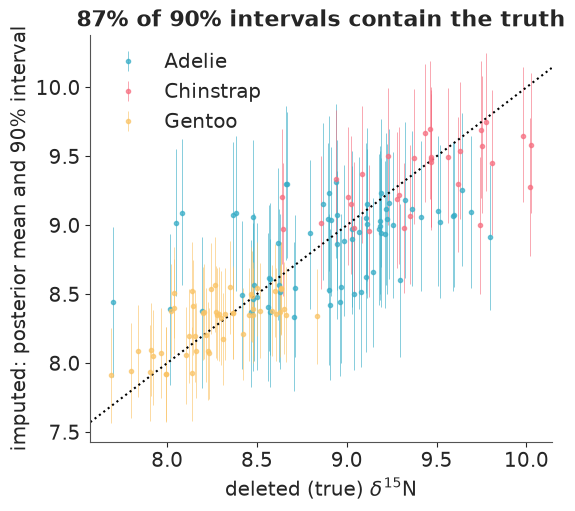

In [15]:
imputed = mar_fits["joint model"].posterior["d15n_unobserved"]
imp_mean = imputed.mean(("chain", "draw")).values
imp_lo, imp_hi = imputed.quantile([0.05, 0.95], dim=("chain", "draw")).values
truth = x_full[deleted]
covered = ((truth >= imp_lo) & (truth <= imp_hi)).mean()

fig, ax = plt.subplots(figsize=(5.5, 5))
sp_deleted = complete.species[deleted].to_numpy()
for k, name in enumerate(SPECIES):
    sel = sp_deleted == name
    ax.errorbar(truth[sel], imp_mean[sel], yerr=[imp_mean[sel] - imp_lo[sel], imp_hi[sel] - imp_mean[sel]],
                fmt="o", ms=3, lw=0.6, alpha=0.7, color=f"C{k}", label=name)
ax.axline((8.5, 8.5), slope=1, color="k", ls=":")
ax.set(xlabel=r"deleted (true) $\delta^{15}$N", ylabel="imputed: posterior mean and 90% interval",
       title=f"{covered:.0%} of 90% intervals contain the truth")
ax.legend();

The point estimates track the truth only loosely - species and season carry most of the
information, an individual's mass very little - and that is fine. Imputation is not about
guessing the value; it is about carrying the right **distribution** for it, and the
interval coverage says the distribution is about right. A filled-in mean is the same picture with every error
bar set to zero.

## 5 · A missing *discrete* covariate: marginalise it

Sex is missing for 9 of the measured birds. Sex is not a nuisance here: males are about
0.7 kg heavier *and* feed slightly higher in the food web, so leaving it out would confound
$\beta_N$. The logic of section 4 applies unchanged - give sex a distribution,
$\text{male}_i \sim \text{Bernoulli}(\pi)$ - but the mechanics do not, because **NUTS cannot
sample a discrete variable**. Write the Bernoulli anyway and `pm.sample` quietly abandons
nutpie for PyMC's own `CompoundStep` of NUTS plus `BinaryGibbsMetropolis`. With 9 binary
unknowns that works; it mixes poorly when the discrete states are many or strongly coupled,
and every gradient-based tool (nutpie, JAX, ADVI, Pathfinder) is off the table.

The better route is the one from **E04**: sum the discrete variable out. For an unsexed bird
the likelihood of what we *did* observe is a two-component mixture,

$$
p(x_i, y_i) = \sum_{s \in \{0, 1\}} \pi^s (1-\pi)^{1-s}\; p(x_i \mid s)\; p(y_i \mid x_i, s),
$$

with $x$ = $\delta^{15}$N and $y$ = mass, and the posterior probability that bird $i$ is male
falls out of the same two terms by Bayes' rule. By hand this is a `logsumexp` inside a
`pm.Potential`. One wrinkle: 3 of the 9 unsexed birds have no isotope value either. Their
$x_i$ is a continuous unknown whose density is already inside the sum, so we declare it
`pm.Flat` - a placeholder that adds nothing to the log-density.

In [16]:
has_mass = peng.dropna(subset=["mass"])
unsexed = has_mass[has_mass.male.isna()]
sp_u, yr_u, _ = design(unsexed)
x_u_missing = unsexed.d15n.isna().to_numpy()
print(f"unsexed birds: {len(unsexed)}, of which without d15N: {x_u_missing.sum()}")

coords = {"species": SPECIES, "year": YEARS, "unsexed": unsexed.index, "unsexed_no_x": unsexed.index[x_u_missing]}

with pm.Model(coords=coords) as mixture_model:
    p = penguin_priors()
    pi = pm.Beta("p_male", 2, 2)

    # the 333 birds of known sex: exactly as before, plus sex itself as data for pi
    sexed_likelihood(p, sexed, sexed.d15n.to_numpy(), suffix="_sexed")
    pm.Bernoulli("male_sexed", pi, observed=sexed.male.to_numpy())

    # the 9 unsexed birds
    x_gap = pm.Flat("d15n_unsexed_missing", dims="unsexed_no_x")
    x_u = pt.set_subtensor(pt.as_tensor(unsexed.d15n.fillna(0.0).to_numpy())[x_u_missing], x_gap)

    def logp_if(s):
        """log [ p(sex = s) p(x | s) p(y | x, s) ] for every unsexed bird."""
        log_prior = pt.log(pi) if s == 1 else pt.log1p(-pi)
        x_dist = pm.Normal.dist(p["mu_x"][sp_u, yr_u] + p["g_x"] * s, p["s_x"][sp_u])
        y_dist = pm.Normal.dist(p["a"][sp_u, yr_u] + p["b_male"] * s + p["b_n"] * (x_u - X_REF), p["sigma"])
        return log_prior + pm.logp(x_dist, x_u) + pm.logp(y_dist, unsexed.mass.to_numpy())

    lp = pt.stack([logp_if(0), logp_if(1)])                       # shape (2, 9)
    pm.Potential("unsexed_loglik", pm.math.logsumexp(lp, axis=0).sum())
    pm.Deterministic("prob_male", pm.math.sigmoid(lp[1] - lp[0]), dims="unsexed")   # Bayes' rule, per draw

    mixture_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

check(mixture_idata, "hand-written mixture (342 rows)")
az.summary(mixture_idata, var_names=["b_n", "b_male", "g_x", "p_male", "sigma"], ci_kind="hdi", ci_prob=0.94,
           round_to=3)

unsexed birds: 9, of which without d15N: 3


hand-written mixture (342 rows)    divergences  0   max r_hat 1.004   min ess_bulk 1,478


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b_n,-0.202,0.060,-0.309,-0.084,1477.826,1861.018,1.003,0.002,0.001
b_male,0.701,0.035,0.633,0.766,2633.941,2990.067,1.000,0.001,0.000
g_x,0.135,0.028,0.084,0.189,2985.839,2883.748,1.001,0.001,0.000
p_male,0.497,0.027,0.445,0.546,7276.402,2721.626,1.002,0.000,0.000
sigma,0.312,0.012,0.290,0.336,7545.306,3139.762,1.000,0.000,0.000


Every measured bird is now in the model: 342 rows instead of the 324 complete cases. nutpie
sampled it without complaint - there is nothing discrete left.

### The same thing, automatically

`pymc_extras.marginalize` does the algebra for you. Write the model the *generative* way,
with a Bernoulli for the unknown sexes, and ask for it to be summed out; `recover` then
draws the sexes back, conditional on each posterior draw. Two practical findings from this
environment (pymc-extras 0.15): the automatic imputation of section 3 cannot sit downstream
of a marginalised variable (`marginalize` raises `NotImplementedError` on the boolean
indexing it generates), so the unsexed birds are split into those with and those without an
isotope value, and the missing isotope values are written as an ordinary latent `pm.Normal`.

In [17]:
with pm.Model(coords={"species": SPECIES, "year": YEARS}) as generative_model:
    p = penguin_priors()
    pi = pm.Beta("p_male", 2, 2)
    sexed_likelihood(p, sexed, sexed.d15n.to_numpy(), suffix="_sexed")
    pm.Bernoulli("male_sexed", pi, observed=sexed.male.to_numpy())

    for group, rows in [("with_x", unsexed[~x_u_missing]), ("no_x", unsexed[x_u_missing])]:
        sp_g, yr_g, _ = design(rows)
        male = pm.Bernoulli(f"male_{group}", pi, shape=len(rows))
        x_mu = p["mu_x"][sp_g, yr_g] + p["g_x"] * male
        if group == "with_x":
            x_g = pm.Normal(f"d15n_{group}", x_mu, p["s_x"][sp_g], observed=rows.d15n.to_numpy())
        else:
            x_g = pm.Normal(f"d15n_{group}", x_mu, p["s_x"][sp_g])          # latent, no data
        pm.Normal(f"mass_{group}", p["a"][sp_g, yr_g] + p["b_male"] * male + p["b_n"] * (x_g - X_REF), p["sigma"],
                  observed=rows.mass.to_numpy())

marginal_model = marginalize(generative_model, ["male_with_x", "male_no_x"])
with marginal_model:
    marginal_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
check(marginal_idata, "pymc_extras.marginalize")
recover(marginal_idata, model=marginal_model, random_seed=RANDOM_SEED)

recovered = np.concatenate([marginal_idata.posterior[f"male_{g}"].mean(("chain", "draw")).values
                            for g in ("with_x", "no_x")])
sex_table = pd.concat([unsexed[~x_u_missing], unsexed[x_u_missing]])[["species", "year", "mass", "bill_depth", "d15n"]]
sex_table["P(male) by hand"] = mixture_idata.posterior["prob_male"].mean(("chain", "draw")).to_series()
sex_table["P(male) marginalize + recover"] = recovered
print("b_n by hand: {:.3f}   marginalize: {:.3f}".format(
    float(mixture_idata.posterior["b_n"].mean()), float(marginal_idata.posterior["b_n"].mean())))
sex_table.round(2)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pymc_extras/model/marginal/distributions/enumerable.py:226: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: d15n_with_x{[9.13362 8 ... 8 8.04111]}.
  warn_non_separable_logp(values)
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pymc_extras/model/marginal/distributions/enumerable.py:226: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: d15n_no_x.
  warn_non_separable_logp(values)


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pymc_extras/model/marginal/distributions/enumerable.py:226: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: d15n_with_x{[9.13362 8 ... 8 8.04111]}.
  warn_non_separable_logp(values)
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pymc_extras/model/marginal/distributions/enumerable.py:226: NonSeparableLogpWarning: There are multiple dependent variables in a FiniteDiscreteMarginalRV. Their joint logp terms will be assigned to the first value: d15n_no_x.
  warn_non_separable_logp(values)


pymc_extras.marginalize            divergences  0   max r_hat 1.004   min ess_bulk 1,506


b_n by hand: -0.202   marginalize: -0.205


,species,year,mass,bill_depth,d15n,P(male) by hand,P(male) marginalize + recover
9,Adelie,2007,4.25,20.2,9.13,0.98,0.98
10,Adelie,2007,3.30,17.1,8.63,0.02,0.02
178,Gentoo,2007,4.10,14.3,7.97,0.00,0.00
218,Gentoo,2008,4.65,14.4,8.24,0.03,0.03
256,Gentoo,2009,4.72,13.8,8.26,0.05,0.04
268,Gentoo,2009,4.88,15.7,8.04,0.05,0.04
8,Adelie,2007,3.48,18.1,NaN,0.18,0.18
11,Adelie,2007,3.70,17.3,NaN,0.48,0.49
47,Adelie,2007,2.98,18.9,NaN,0.01,0.01


The two routes agree to Monte Carlo accuracy. (The hand-written `prob_male` averages exact
probabilities; the recovered column averages 0/1 draws, so it is a little noisier.)

**Check the imputed sexes against something the model never saw.** Bill depth is strongly
sexually dimorphic and was not used. Plot each unsexed bird among the sexed birds of its
species:

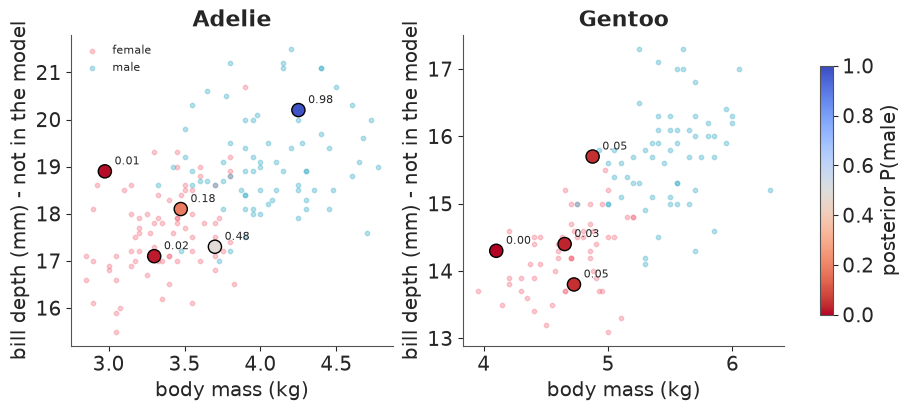

In [18]:
prob_male = mixture_idata.posterior["prob_male"].mean(("chain", "draw")).to_series()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name in zip(axes, ["Adelie", "Gentoo"]):
    known = sexed[sexed.species == name]
    for s, color, label in [(0, "C1", "female"), (1, "C0", "male")]:
        grp = known[known.male == s]
        ax.scatter(grp.mass, grp.bill_depth, s=10, color=color, alpha=0.35, label=label)
    who = unsexed[unsexed.species == name]
    sc = ax.scatter(who.mass, who.bill_depth, c=prob_male[who.index], cmap="coolwarm_r", vmin=0, vmax=1, s=90,
                    edgecolor="k", zorder=3)
    for i, r in who.iterrows():
        ax.annotate(f"{prob_male[i]:.2f}", (r.mass, r.bill_depth), textcoords="offset points", xytext=(7, 5),
                    fontsize=8)
    ax.set(title=name, xlabel="body mass (kg)", ylabel="bill depth (mm) - not in the model")
axes[0].legend(fontsize=8)
fig.colorbar(sc, ax=axes, label="posterior P(male)", shrink=0.8);

The large symbols are the unsexed birds, labelled with their posterior probability of being
male. The probabilities follow body mass, as they must - mass is the only strongly dimorphic
variable the model has - and bill depth mostly agrees: the one confident "male" has the
deepest bill, the 50:50 bird sits where the clouds overlap. Two birds deserve a second look:
the lightest Adelie and the heaviest unsexed Gentoo are called female with 95-99% confidence
on mass alone, yet their bills are deep enough to sit among the males. The plot is telling
you how to improve the model: give bill depth a sex-dependent likelihood too. That is one
more line per measurement, and the third exercise below.

**Did any of this change the answer?**

In [19]:
part1 = {"complete cases (324 birds)": full_idata, "impute d15N (333 birds)": joint_idata,
         "+ marginalise sex (342 birds)": mixture_idata}
coef_table(part1)

,b_n mean,b_n std,b_male mean,b_male std,sigma mean,sigma std
complete cases (324 birds),-0.203,0.058,0.703,0.035,0.311,0.012
impute d15N (333 birds),-0.204,0.060,0.696,0.036,0.312,0.012
+ marginalise sex (342 birds),-0.202,0.060,0.701,0.035,0.312,0.012


No - and with 20 incomplete rows out of 344, and mechanisms as benign as field logistics,
it should not. That is a *result*: we now know the conclusion does not hinge on the dropped
rows, which a complete-case analysis can only assume. The deletion experiment showed how
quickly that changes when more is missing or the mechanism touches the outcome.

## 6 · MNAR: when the value causes its own absence

Everything so far assumed MAR. To make MNAR concrete, delete values with a mechanism that
depends **on the value itself**: suppose the isotope lab fails more often on samples high in
$\delta^{15}$ N,

$$P(\delta^{15}\text{N}_i \text{ missing}) = \text{logit}^{-1}\big(-0.5 + 2\,(\delta^{15}\text{N}_i - 8.7)\big).$$

The target this time is a descriptive one that this mechanism should damage: **the mean
$\delta^{15}$ N of each species** among these 324 birds - which we know exactly.

In [20]:
def delete_mnar(seed):
    """Boolean mask of deleted d15N values: the higher the value, the likelier it is lost."""
    return np.random.default_rng(seed).random(len(complete)) < expit(-0.5 + 2.0 * (x_full - X_REF))


gone_mnar = delete_mnar(RANDOM_SEED + 100)
d15n_mnar = np.where(gone_mnar, np.nan, x_full)
print(f"deleted {gone_mnar.sum()} of {len(complete)} values ({gone_mnar.mean():.0%}); share deleted by species:")
print(pd.Series(gone_mnar).groupby(complete.species).mean().round(2).to_string())

mar_model, mar_idata = fit_mass(complete, d15n_mnar)                       # assumes MAR: ignores the mechanism
sel_model, sel_idata = fit_mass(complete, d15n_mnar, selection=True)      # models the mechanism
check(mar_idata, "MAR joint model")
check(sel_idata, "selection model")
print(az.summary(sel_idata, var_names=["c0", "c1"], ci_kind="hdi", ci_prob=0.94, round_to=2)
      [["mean", "sd", "hdi94_lb", "hdi94_ub"]])
coef_table({"full data": full_idata, "MAR joint model": mar_idata, "selection model": sel_idata})

deleted 133 of 324 values (41%); share deleted by species:
species
Adelie       0.48
Chinstrap    0.61
Gentoo       0.21


MAR joint model                    divergences  0   max r_hat 1.004   min ess_bulk 996
selection model                    divergences  0   max r_hat 1.006   min ess_bulk 955
    mean    sd  hdi94_lb  hdi94_ub
c0 -0.52  0.14     -0.79     -0.26
c1  1.97  0.31      1.41      2.59


,b_n mean,b_n std,b_male mean,b_male std,sigma mean,sigma std
full data,-0.203,0.058,0.703,0.035,0.311,0.012
MAR joint model,-0.112,0.082,0.686,0.036,0.315,0.013
selection model,-0.100,0.076,0.686,0.037,0.315,0.013


The **selection model** is the MAR model plus one line (see `fit_mass`): the missingness
indicator gets a Bernoulli likelihood whose logit depends on the *completed* covariate
vector - observed values where we have them, the latent imputations where we do not. The
imputations are now pulled by three things: the covariate model, the bird's mass, and the
fact that the value *went missing*.

In [21]:
sp_complete = complete.species.to_numpy()
true_means = pd.Series(x_full).groupby(sp_complete).mean()
observed_means = pd.Series(x_full[~gone_mnar]).groupby(sp_complete[~gone_mnar]).mean()

rows = {}
for label, idata in [("MAR joint model", mar_idata), ("selection model", sel_idata)]:
    completed = idata.posterior["d15n"].stack(sample=("chain", "draw")).values      # (bird, sample)
    for name in SPECIES:
        draws = completed[sp_complete == name].mean(axis=0)
        lo, hi = np.quantile(draws, [0.03, 0.97])
        rows[(name, label)] = {"estimate": draws.mean(), "3%": lo, "97%": hi}
mnar_table = pd.DataFrame(rows).T
mnar_table.insert(0, "true mean", [true_means[k[0]] for k in mnar_table.index])
mnar_table.insert(1, "mean of survivors", [observed_means[k[0]] for k in mnar_table.index])
mnar_table.round(3)

,,true mean,mean of survivors,estimate,3%,97%
Adelie,MAR joint model,8.859,8.724,8.767,8.711,8.826
Chinstrap,MAR joint model,9.356,9.109,9.212,9.124,9.305
Gentoo,MAR joint model,8.249,8.219,8.230,8.211,8.248
Adelie,selection model,8.859,8.724,8.890,8.820,8.965
Chinstrap,selection model,9.356,9.109,9.294,9.207,9.396
Gentoo,selection model,8.249,8.219,8.247,8.228,8.267


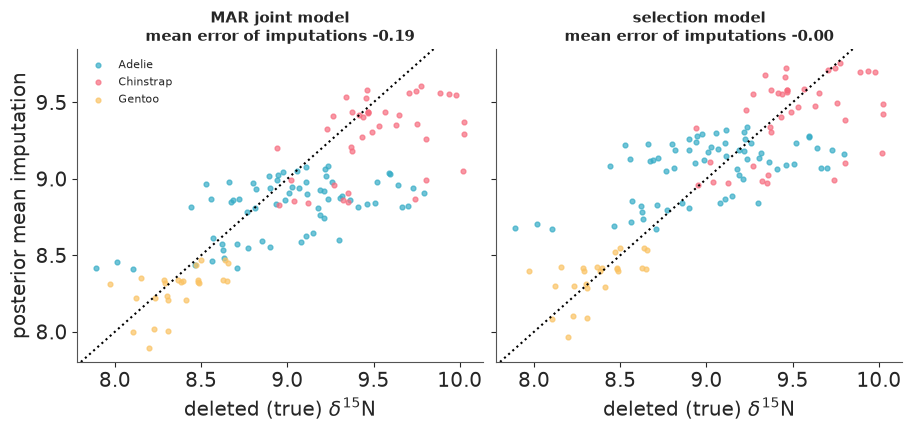

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)
for ax, (label, idata) in zip(axes, [("MAR joint model", mar_idata), ("selection model", sel_idata)]):
    imp = idata.posterior["d15n_unobserved"].mean(("chain", "draw")).values
    for k, name in enumerate(SPECIES):
        sel = sp_complete[gone_mnar] == name
        ax.scatter(x_full[gone_mnar][sel], imp[sel], s=12, alpha=0.7, color=f"C{k}", label=name)
    ax.axline((8.5, 8.5), slope=1, color="k", ls=":")
    ax.set_title(f"{label}\nmean error of imputations {np.mean(imp - x_full[gone_mnar]):+.2f}", fontsize=11)
    ax.set(xlabel=r"deleted (true) $\delta^{15}$N")
axes[0].set(ylabel="posterior mean imputation")
axes[0].legend(fontsize=8);

Under MNAR the MAR model is **biased and confident**: its imputations look like the
survivors, the survivors are the low values, and its 94% intervals for all three species
means miss the truth (Gentoo, which lost the fewest values, only just). The selection model
recovers the mechanism (`c0`, `c1`; we used -0.5 and 2), its imputations are unbiased on
average, and all three intervals now contain the true mean - with wider intervals, as they
should be.

Now the coefficient table. $\beta_N$ is the same in the two fits: modelling the mechanism did
nothing for it, and in theory it did not need to, because selection on a **covariate** does
not bias a correctly specified regression *on* that covariate. MNAR damages what the mechanism
points at. Yet both estimates are only half the full-data value. How much of that is bad luck
in one deletion? Least squares on the survivors, repeated 500 times, answers in milliseconds:

In [23]:
cc_slopes = np.array([ols_b_n(~delete_mnar(k), x_full) for k in range(500)])
print(f"complete-case slope over 500 MNAR deletions: mean {cc_slopes.mean():.3f}, sd {cc_slopes.std():.3f}   "
      f"(this deletion: {ols_b_n(~gone_mnar, x_full):.3f}, full data: {target:.3f})")

complete-case slope over 500 MNAR deletions: mean -0.145, sd 0.053   (this deletion: -0.103, full data: -0.198)


Mostly luck - this deletion sits almost one sd on the unlucky side - plus a smaller systematic
part: on average the survivors give about three quarters of the full-data slope. "Selection on
a covariate is harmless" holds for a *correctly specified* regression, and real penguins are
not exactly linear in $\delta^{15}$N: remove the high values and the best-fitting line
changes. No missing-data method repairs that; it is ordinary model misspecification, made
visible by the deletion.

Before filing this under "solved", be clear about **where the identification comes from**,
because the data cannot verify any of it:

1. the *shape* assumptions - $\delta^{15}$N is Normal within a group, the mechanism is
   logistic-linear. A selection model reads skewness in the observed values as evidence of
   selection. If the true distribution were skewed, it would "correct" a bias that is not there;
2. an *exclusion restriction* - species, season, sex and mass predict $\delta^{15}$N but are
   assumed to affect missingness only through it. The very different deletion rates across
   species are what pin down `c1`.

We generated the data this way, so the model is right by construction. With real MNAR data
you would not know, and the honest workflow is a **sensitivity analysis**: fix `c1` at a few
plausible values and report how far the conclusions move.

## 7 · Measurement error: when the data are themselves estimates

New data, same idea. The divorce and marriage rates of the US states are **survey
estimates**, published with standard errors. A textbook regression treats 50 numbers of very
different quality as equally exact.

In [24]:
data.describe("waffle_divorce")
waffle = data.load("waffle_divorce")
waffle[["Location", "Population", "MedianAgeMarriage", "Marriage", "Marriage SE", "Divorce", "Divorce SE"]] \
    .sort_values("Population").iloc[[0, 1, 2, -3, -2, -1]]

waffle_divorce: Divorce and marriage rates for 50 US states WITH their standard errors, plus median age at marriage.
  source: US Census / American Community Survey state statistics, via McElreath's `rethinking`.
  url:    https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/WaffleDivorce.csv


,Location,Population,MedianAgeMarriage,Marriage,Marriage SE,Divorce,Divorce SE
49,Wyoming,0.56,24.2,30.7,3.92,10.3,1.90
8,District of Columbia,0.60,29.7,17.7,2.53,6.3,1.89
44,Vermont,0.63,26.9,16.4,2.40,9.6,1.87
31,New York,19.38,28.4,16.8,0.47,6.6,0.31
42,Texas,25.15,25.2,21.5,0.61,10.0,0.35
4,California,37.25,26.8,19.1,0.39,8.0,0.24


Divorce SE ranges from 0.24 to 2.5; the sd of the divorce rates themselves is 1.82


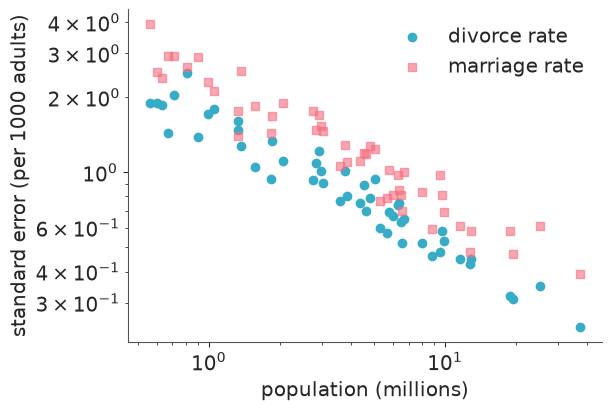

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(waffle.Population, waffle["Divorce SE"], label="divorce rate")
ax.scatter(waffle.Population, waffle["Marriage SE"], marker="s", alpha=0.6, label="marriage rate")
ax.set(xscale="log", yscale="log", xlabel="population (millions)", ylabel="standard error (per 1000 adults)")
ax.legend()
print(f"Divorce SE ranges from {waffle['Divorce SE'].min()} to {waffle['Divorce SE'].max()}; "
      f"the sd of the divorce rates themselves is {waffle.Divorce.std():.2f}")

The standard errors fall with population like $1/\sqrt{n}$ and span a factor of ten. For
South Dakota, Alaska or Wyoming the error is as large as the whole between-state spread; for
California it is negligible.

*Does a state's divorce rate depend on its marriage rate, once median age at marriage is
accounted for?* (McElreath's running example, *Statistical Rethinking* ch. 5 and 15. We
standardise all three variables, and the standard errors with them.)

The measurement-error model adds one layer. The regression is about the **true** rate,
which is latent; the published rate is a noisy reading of it with **known** sd:

$$
\begin{aligned}
D^\text{true}_i &\sim \text{Normal}(\alpha + \beta_A A_i + \beta_M M_i,\ \sigma) \\
D^\text{obs}_i &\sim \text{Normal}(D^\text{true}_i,\ \text{SE}_i)
\end{aligned}
$$

Error in a **predictor** is handled the same way, and as in section 4 the latent predictor
needs a distribution of its own - a covariate model. Marriage rate and age at marriage are
strongly correlated (-0.72), so that model conditions on age:
$M^\text{true}_i \sim \text{Normal}(\gamma_0 + \gamma_A A_i, \tau)$, $M^\text{obs}_i \sim
\text{Normal}(M^\text{true}_i, \text{SE}^M_i)$.

In [26]:
def standardize(s):
    return ((s - s.mean()) / s.std()).to_numpy()


D_obs, M_obs, A = standardize(waffle.Divorce), standardize(waffle.Marriage), standardize(waffle.MedianAgeMarriage)
D_se = (waffle["Divorce SE"] / waffle.Divorce.std()).to_numpy()
M_se = (waffle["Marriage SE"] / waffle.Marriage.std()).to_numpy()
STATES = waffle.Loc.to_numpy()


def fit_divorce(error_in=(), likelihood="normal", keep=None, nu=None):
    """Divorce ~ age + marriage. error_in: subset of {"D", "M"}; likelihood: "normal" or "student"."""
    keep = np.ones(len(waffle), dtype=bool) if keep is None else keep
    with pm.Model(coords={"state": STATES[keep]}) as model:
        a = pm.Normal("a", 0, 0.2)
        bA = pm.Normal("bA", 0, 0.5)
        bM = pm.Normal("bM", 0, 0.5)
        sigma = pm.Exponential("sigma", 1)

        if "M" in error_in:
            g0, gA, tau = pm.Normal("g0", 0, 0.2), pm.Normal("gA", 0, 0.5), pm.Exponential("tau", 1)
            M = pm.Normal("M_true", g0 + gA * A[keep], tau, dims="state")
            pm.Normal("M_obs", M, M_se[keep], observed=M_obs[keep], dims="state")
        else:
            M = M_obs[keep]

        mu = a + bA * A[keep] + bM * M
        if "D" in error_in:
            D_true = pm.Normal("D_true", mu, sigma, dims="state")
            pm.Normal("D_obs", D_true, D_se[keep], observed=D_obs[keep], dims="state")
        elif likelihood == "student":
            nu = pm.Gamma("nu", 2, 0.1) if nu is None else nu
            pm.StudentT("D_obs", nu=nu, mu=mu, sigma=sigma, observed=D_obs[keep], dims="state")
        else:
            pm.Normal("D_obs", mu, sigma, observed=D_obs[keep], dims="state")

        # up to 100 latent values make the chains more autocorrelated: take more draws for those fits
        idata = pm.sample(draws=2000 if error_in else 1000, random_seed=RANDOM_SEED, progressbar=False)
    return model, idata


naive_model, naive_idata = fit_divorce()
errD_model, errD_idata = fit_divorce(error_in=("D",))
errDM_model, errDM_idata = fit_divorce(error_in=("D", "M"))

divorce_fits = {"naive": naive_idata, "error in D": errD_idata, "error in D and M": errDM_idata}
for label, idata in divorce_fits.items():
    check(idata, label)
coef_table(divorce_fits, var_names=("bA", "bM", "sigma"))

naive                              divergences  0   max r_hat 1.000   min ess_bulk 2,005
error in D                         divergences  0   max r_hat 1.004   min ess_bulk 1,951


error in D and M                   divergences  1   max r_hat 1.003   min ess_bulk 1,421


,bA mean,bA std,bM mean,bM std,sigma mean,sigma std
naive,-0.604,0.158,-0.058,0.156,0.827,0.086
error in D,-0.615,0.157,0.050,0.164,0.585,0.107
error in D and M,-0.482,0.195,0.281,0.262,0.558,0.113


Priors are the standard weakly-informative ones for standardised variables: slopes beyond
$\pm 1$ are implausible, so `Normal(0, 0.5)`. All three fits are clean, including the one
with 100 latent state-level values (a stray divergence among its 8000 draws, if you see one,
is no cause for concern with `r_hat` and ESS like these).

- **Error in the outcome** leaves the slopes roughly where they were but cuts $\sigma$
  substantially: part of what the naive model called unexplained variation between states
  is survey noise, and we knew its size all along.
- **Error in the predictor** changes the *story*. Noise in a predictor biases its
  coefficient towards zero (**attenuation**), and because marriage rate and age are
  correlated, the variance the noisy predictor failed to explain had been credited to age.
  Modelling the error moves $\beta_M$ up and shrinks $|\beta_A|$. The intervals widen too -
  the honest price of admitting that the predictor is not known.

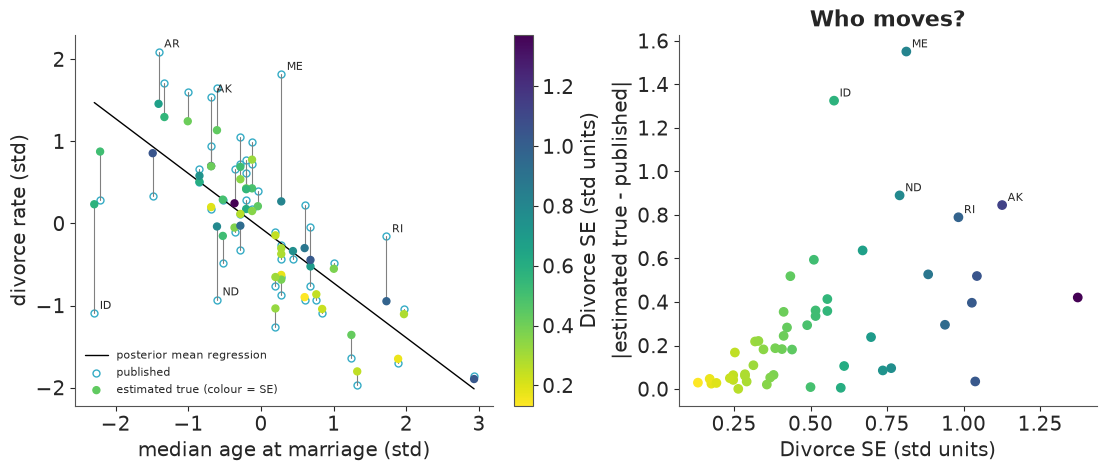

In [27]:
D_true = errDM_idata.posterior["D_true"].mean(("chain", "draw")).values
M_true = errDM_idata.posterior["M_true"].mean(("chain", "draw")).values
post = az.extract(errDM_idata, var_names=["a", "bA", "gA", "g0", "bM"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
grid = np.linspace(A.min(), A.max(), 50)
line = (post["a"].values + post["bA"].values * grid[:, None]
        + post["bM"].values * (post["g0"].values + post["gA"].values * grid[:, None])).mean(axis=1)
ax.plot(grid, line, color="k", lw=1, label="posterior mean regression")
ax.scatter(A, D_obs, s=25, facecolor="w", edgecolor="C0", label="published")
sc = ax.scatter(A, D_true, s=25, c=D_se, cmap="viridis_r", zorder=3, label="estimated true (colour = SE)")
for i in range(len(A)):
    ax.plot([A[i], A[i]], [D_obs[i], D_true[i]], color="grey", lw=0.8)
    if abs(D_true[i] - D_obs[i]) > 0.6:
        ax.annotate(STATES[i], (A[i], D_obs[i]), textcoords="offset points", xytext=(4, 3), fontsize=8)
ax.set(xlabel="median age at marriage (std)", ylabel="divorce rate (std)")
ax.legend(fontsize=8, loc="lower left")
fig.colorbar(sc, ax=ax, label="Divorce SE (std units)")

ax = axes[1]
ax.scatter(D_se, np.abs(D_true - D_obs), c=D_se, cmap="viridis_r")
for i in np.argsort(-np.abs(D_true - D_obs))[:5]:
    ax.annotate(STATES[i], (D_se[i], abs(D_true[i] - D_obs[i])), textcoords="offset points", xytext=(4, 3), fontsize=8)
ax.set(xlabel="Divorce SE (std units)", ylabel="|estimated true - published|", title="Who moves?");

This is **shrinkage**, the same mechanism as partial pooling in E02. Each state's estimated
true rate is a precision-weighted compromise between its published value and what the
regression expects for a state like it. Precisely measured states (light colours) do not
move. Noisy ones move towards the line, and they move furthest when they are both noisy
*and* far from it - Maine, Idaho, North Dakota. Nobody was deleted, nobody was
down-weighted by hand; the likelihood $\text{Normal}(D^\text{true}_i, \text{SE}_i)$ did the
weighting.

### The same model without the latent variables

Two Normals in a row integrate analytically:
$D^\text{obs}_i \sim \text{Normal}\big(\mu_i, \sqrt{\sigma^2 + \text{SE}_i^2}\big)$ - a
**heteroskedastic likelihood with a known variance component**. No latent vector, same
posterior for the parameters:

In [28]:
with pm.Model() as marginal_divorce:
    a, bA, bM = pm.Normal("a", 0, 0.2), pm.Normal("bA", 0, 0.5), pm.Normal("bM", 0, 0.5)
    sigma = pm.Exponential("sigma", 1)
    pm.Normal("D_obs", a + bA * A + bM * M_obs, pt.sqrt(sigma**2 + D_se**2), observed=D_obs)
    marginal_divorce_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

coef_table({"latent D_true": errD_idata, "integrated out": marginal_divorce_idata}, var_names=("bA", "bM", "sigma"))

,bA mean,bA std,bM mean,bM std,sigma mean,sigma std
latent D_true,-0.615,0.157,0.050,0.164,0.585,0.107
integrated out,-0.617,0.157,0.048,0.165,0.587,0.106


Strip out the predictors and this is **random-effects meta-analysis**: study estimates
$y_j \pm \text{SE}_j$, true effects $\theta_j \sim \text{Normal}(\mu, \tau)$ - the eight-schools
model is a measurement-error model. The same two lines handle any input that arrives with an
error bar: poll results, small-area statistics, instrument readings, the output of a
previous model. (Keep the latent form when you want the $D^\text{true}_i$ themselves, or
when the error is in a predictor, where nothing integrates out so neatly.)

## 8 · Outliers and heavy tails

The third kind of imperfection is the point that does not fit. The reflex is to find it and
delete it. The Bayesian workflow has better tools for both halves of that sentence.

### Find influential points with PSIS-LOO, not by eye

PSIS-LOO approximates leaving each observation out in turn. Two pointwise by-products: the
**Pareto $\hat k$** says how much the posterior would change without that point (above 0.7
the approximation itself fails - the point is *highly* influential), and **`elpd_i`** says how
surprising the point is to a model that has not seen it.

In [29]:
with naive_model:
    pm.compute_log_likelihood(naive_idata, progressbar=False)
naive_loo = az.loo(naive_idata, pointwise=True)

influence = pd.DataFrame({
    "pareto_k": naive_loo.pareto_k.values, "elpd_i": naive_loo.elpd_i.values,
    "Divorce": waffle.Divorce.values, "Divorce SE": waffle["Divorce SE"].values,
    "MedianAgeMarriage": waffle.MedianAgeMarriage.values,
}, index=STATES)
influence.sort_values("pareto_k", ascending=False).head(5).round(2)

,pareto_k,elpd_i,Divorce,Divorce SE,MedianAgeMarriage
ID,0.62,-6.25,7.7,1.05,23.2
DC,0.43,-0.89,6.3,1.89,29.7
ND,0.30,-1.94,8.0,1.44,25.3
AR,0.29,-2.24,13.5,1.22,24.3
ME,0.29,-3.88,13.0,1.48,26.4


No $\hat k$ crosses 0.7, so nothing is pathological, but **Idaho** stands apart on both
columns. The two columns measure different things: the District of Columbia has the
second-highest $\hat k$ because its age at marriage is extreme (leverage), yet it is well
predicted; **Maine** has an ordinary $\hat k$ but is the second most *surprising* state.
Idaho marries young and divorces little (the usual explanation is its large Latter-day
Saints population); Maine divorces far more than its age at marriage suggests. Three
responses:

1. **delete** Idaho and refit;
2. a **Student-t likelihood**, which expects an occasional large residual and therefore
   lets one pull less;
3. ask whether the point is an outlier at all, or a *noisy measurement* - which we do last.

### What $\nu$ means

The Student-t has one extra parameter, the degrees of freedom $\nu$. At $\nu = 1$ it is the
Cauchy; below about 5 the tails are heavy enough to shrug off a gross outlier; by
$\nu \approx 30$ it is indistinguishable from a Normal. $\nu$ is a statement about *how
often* wild residuals occur, so it is informed only by the tails - and 50 data points have
hardly any tail. A sensible default prior is `Gamma(2, 0.1)` (mean 20, most mass between 3
and 50; Juarez and Steel 2010), which lets the data argue for heavy tails without presuming
them. The alternative is to *fix* a small $\nu$ as a deliberate robustness assumption, as
McElreath does with $\nu = 2$. Note that `sigma` of a Student-t is a scale, not a standard
deviation: do not compare it with the Normal's `sigma`.

In [30]:
student_model, student_idata = fit_divorce(likelihood="student")
_, student2_idata = fit_divorce(likelihood="student", nu=2.0)
_, no_idaho_idata = fit_divorce(keep=STATES != "ID")

robust_fits = {"Normal, all 50 states": naive_idata, "Normal, Idaho deleted": no_idaho_idata,
               "Student-t, nu ~ Gamma(2, 0.1)": student_idata, "Student-t, nu = 2": student2_idata}
for label, idata in robust_fits.items():
    check(idata, label)

nu = az.extract(student_idata, var_names="nu").values
prior_q = stats.gamma(2, scale=10).ppf([0.03, 0.5, 0.97])
print(f"\nposterior of nu: median {np.median(nu):.0f}, 94% interval {np.quantile(nu, [0.03, 0.97]).round(0)}"
      f"   (the Gamma(2, 0.1) prior: median {prior_q[1]:.0f}, 94% interval {prior_q[[0, 2]].round(0)})")
coef_table(robust_fits, var_names=("bA", "bM"))

Normal, all 50 states              divergences  0   max r_hat 1.000   min ess_bulk 2,005
Normal, Idaho deleted              divergences  0   max r_hat 1.002   min ess_bulk 2,044
Student-t, nu ~ Gamma(2, 0.1)      divergences  0   max r_hat 1.002   min ess_bulk 2,558
Student-t, nu = 2                  divergences  0   max r_hat 1.001   min ess_bulk 2,619

posterior of nu: median 17, 94% interval [ 4. 52.]   (the Gamma(2, 0.1) prior: median 17, 94% interval [ 3. 54.])


,bA mean,bA std,bM mean,bM std
"Normal, all 50 states",-0.604,0.158,-0.058,0.156
"Normal, Idaho deleted",-0.751,0.146,-0.082,0.140
"Student-t, nu ~ Gamma(2, 0.1)",-0.639,0.157,-0.043,0.159
"Student-t, nu = 2",-0.696,0.150,0.046,0.199


In [31]:
with student_model:
    pm.compute_log_likelihood(student_idata, progressbar=False)
az.compare({"Normal": naive_idata, "Student-t": student_idata}, round_to=1)

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Student-t,0,0.0,0.0,NaN,,,4.7,-63.4,6.2,1.0
Normal,1,-0.5,0.8,0.7,N < 100,,4.8,-63.9,6.5,0.0


- Deleting one state out of 50 moves $\beta_A$ by about one posterior standard deviation.
  That is what "influential" means.
- The Student-t with a free $\nu$ barely reacts: the posterior of $\nu$ is essentially its
  prior, because a single moderately unusual state is no evidence of heavy tails. LOO cannot
  separate the two likelihoods.
- Fixing $\nu = 2$ *imposes* robustness and moves $\beta_A$ most of the way to the
  Idaho-deleted answer without choosing whom to delete. It is an assumption, stated in the model, that you can defend or
  vary - which is exactly what deleting a row is not.

### Outlier, or data error?

Robust likelihoods are for observations that are **correct but unusual**: the process really
does produce an Idaho now and then, and the model should not be thrown by it. A **data
error** - a unit mix-up, a typo, a noisy instrument - is a different thing, and the right
response is to fix it or to *model the error process*. We have already done the latter for
these data. Look at what the measurement-error model of section 7 made of the two states LOO
singled out:

In [32]:
shift = pd.DataFrame({"Divorce SE": waffle["Divorce SE"].values, "published D (std)": D_obs,
                      "estimated true D (std)": D_true, "shift": D_true - D_obs}, index=STATES)
print(f"median Divorce SE over all states: {waffle['Divorce SE'].median():.2f}")
shift.loc[["ID", "ME"]].round(2)

median Divorce SE over all states: 0.80


,Divorce SE,published D (std),estimated true D (std),shift
ID,1.05,-1.09,0.23,1.33
ME,1.48,1.82,0.27,-1.55


Both "outliers" have above-median standard errors, and the measurement-error model moved
both by more than a full standard deviation of the outcome - further than any other state.
It did what the Student-t was asked to do, discounting an extreme point, but for a reason
we can point to in the data documentation, and only as far as the known SE allows. A
generic heavy tail is the fallback for when you know *nothing* about why a point is off.

## 9 · Rounding, heaping, censoring, truncation

The remaining imperfections are all the same trick: **the likelihood should describe the
number that was written down, not the quantity you wish had been recorded.**

| What happened to the value | Likelihood contribution | PyMC |
|---|---|---|
| recorded exactly | density $f(y)$ | any distribution |
| only known to exceed / fall below a bound (**censored**) | $P(Y > c)$ or $P(Y < c)$ | `pm.Censored` - see **E06** |
| rounded or binned (**interval-censored**) | $F(\text{upper}) - F(\text{lower})$ | `pm.CustomDist` around `pt.round`, or `pm.Potential` |
| rows beyond a bound never enter the dataset (**truncated**) | $f(y) / P(\text{inside})$ | `pm.Truncated` |

The field scales at Palmer were read coarsely, and people like round numbers:

In [33]:
grams = raw["Body Mass (g)"].dropna()
print(f"body masses that are multiples of 25 g: {(grams % 25 == 0).mean():.0%}, "
      f"of 50 g: {(grams % 50 == 0).mean():.0%}, of 100 g: {(grams % 100 == 0).mean():.0%}")

body masses that are multiples of 25 g: 100%, of 50 g: 85%, of 100 g: 48%


Every mass is a multiple of 25 g, and multiples of 50 and 100 are over-represented
(**heaping**). With a residual sd near 300 g a 25-50 g grid is harmless - rounding matters
when the grid is comparable to the spread. To see it matter, pretend the scale had read to
the nearest **kilogram**, and compare three fits of `mass ~ species + sex`.

PyMC can derive the likelihood of a rounded variable by itself: wrap `pt.round` around a
distribution inside `pm.CustomDist` and the log-probability becomes
$\log\big[F(y + \tfrac12) - F(y - \tfrac12)\big]$.

In [34]:
sp_s, _, male_s = design(sexed)
mass_exact = sexed.mass.to_numpy()
mass_rounded = np.round(mass_exact)
print("rounded masses (kg: birds):", {int(k): int(n) for k, n in zip(*np.unique(mass_rounded, return_counts=True))})


def rounded_normal(mu, sigma, size):
    return pt.round(pm.Normal.dist(mu, sigma, size=size))


def fit_rounding(y, interval):
    with pm.Model(coords={"species": SPECIES}):
        a = pm.Normal("a", 4, 1, dims="species")
        b_male = pm.Normal("b_male", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        mu = a[sp_s] + b_male * male_s
        if interval:
            pm.CustomDist("mass", mu, sigma, dist=rounded_normal, observed=y)
        else:
            pm.Normal("mass", mu, sigma, observed=y)
        return pm.sample(random_seed=RANDOM_SEED, progressbar=False)


rounding_fits = {"exact masses": fit_rounding(mass_exact, interval=False),
                 "rounded to 1 kg, Normal likelihood": fit_rounding(mass_rounded, interval=False),
                 "rounded to 1 kg, interval likelihood": fit_rounding(mass_rounded, interval=True)}
for label, idata in rounding_fits.items():
    check(idata, label)
coef_table(rounding_fits, var_names=("sigma", "b_male"))

rounded masses (kg: birds): {3: 68, 4: 153, 5: 79, 6: 33}


exact masses                       divergences  0   max r_hat 1.001   min ess_bulk 1,820
rounded to 1 kg, Normal likelihood divergences  0   max r_hat 1.002   min ess_bulk 2,093
rounded to 1 kg, interval likelihood divergences  0   max r_hat 1.002   min ess_bulk 1,886


,sigma mean,sigma std,b_male mean,b_male std
exact masses,0.318,0.012,0.667,0.035
"rounded to 1 kg, Normal likelihood",0.461,0.018,0.667,0.051
"rounded to 1 kg, interval likelihood",0.347,0.022,0.677,0.048


In [35]:
# trust, but verify: the derived log-probability is the Normal mass of the rounding interval
auto = pm.logp(pm.CustomDist.dist(4.2, 0.3, dist=rounded_normal), 4.0).eval()
by_hand = np.log(stats.norm.cdf(4.5, 4.2, 0.3) - stats.norm.cdf(3.5, 4.2, 0.3))
print(f"pm.logp of the rounded Normal at 4: {auto:.5f}    log[F(4.5) - F(3.5)]: {by_hand:.5f}")

pm.logp of the rounded Normal at 4: -0.18449    log[F(4.5) - F(3.5)]: -0.18449


Treating rounded values as exact **inflates $\sigma$**: the rounding error (variance
$h^2/12$ for a grid of width $h$ - Sheppard's correction) is mistaken for biological
variation. The interval likelihood gives most of it back, with a wider posterior because a
1 kg grid really does destroy information. Location parameters are barely affected, which is
why rounding is usually ignored - until the question is about a *variance*, a tail
probability or a threshold.

## 10 · The decision table

| Data problem | What deleting / ignoring assumes | Model-based alternative | PyMC construct |
|---|---|---|---|
| Missing **outcome** | nothing harmful under MAR (no information lost) | impute only if you need predictions for those rows | `observed=` with `NaN` -> `y_unobserved`, `y_observed`, `y` |
| Missing **continuous covariate** | complete cases are a random subsample (MCAR), or at least missingness is unrelated to the outcome | a distribution for the covariate, conditioned on what predicts it and its missingness | the same `NaN` idiom on the covariate; use the stitched variable downstream |
| Mean / median fill | the value is known exactly and equals the mean | as above | as above |
| Missing **discrete covariate** | as for continuous | mixture over its values; posterior class probabilities by Bayes' rule | `pm.math.logsumexp` + `pm.Potential`, or `pymc_extras.marginalize` + `recover` |
| Value missing **because of** its value (MNAR) | MAR | selection model: likelihood for the missingness indicator given the latent value; then a sensitivity analysis | `pm.Bernoulli("is_missing", logit_p=c0 + c1 * x_completed, observed=...)` |
| Outcome measured **with known error** | measured exactly; equal precision everywhere | latent true value, or add the known variance | `pm.Normal("obs", true, se, observed=...)` or `sigma=pt.sqrt(sigma**2 + se**2)` |
| **Predictor** measured with error | measured exactly (slope attenuated) | latent true predictor with its own model | latent `pm.Normal` + `pm.Normal("x_obs", x_true, se, observed=...)` |
| **Outlier** (correct but unusual) | that point comes from a process you need not describe | heavy-tailed likelihood; find candidates with Pareto $\hat k$ | `pm.StudentT`, `az.loo(pointwise=True)` |
| **Data error** | - | fix at the source, or model the error process (mixture of good and bad readings) | `pm.Mixture`; known SEs as above |
| **Rounded / heaped / binned** | the grid is fine relative to the spread | interval likelihood | `pm.CustomDist` around `pt.round`; `pm.Potential` with `logdiffexp` of `pm.logcdf` |
| **Censored** | censored rows are events, or are ignorable (E06: badly wrong) | survival-function contribution | `pm.Censored` |
| **Truncated** sample | the sample represents the population | renormalised density | `pm.Truncated` |

### Try it yourself

1. **Fool the selection model.** Its identification leans on Normality. Delete 40% of the
   isotope values *completely at random* and fit the selection model: does the interval of
   `c1` include zero, as it should? Now do the same after replacing $\delta^{15}$N by a
   right-skewed version of itself (say `np.exp` of the standardised values) while keeping the
   Normal covariate model. What does the model make of skewness it did not expect? Finally, in
   the original experiment, put a sceptical prior on `c1` (`Normal(0, 0.5)`): how far do the
   species means move back towards the MAR answer?
2. **Make mean-filling flip a sign.** In the deletion experiment of section 4, let the
   mechanism depend on mass standardised over *all* birds instead of within species and sex,
   with slope 3 and intercept 0, so that the small species lose nearly all their isotope
   values. Compare the least-squares estimates over 200 deletions (`ols_b_n` is fast), then
   fit the joint model to a handful of them. Why is mean-filling now *worse* than useless?
3. **Give the unsexed birds a better classifier.** Add bill depth to the hand-written mixture
   of section 5 with a species- and sex-specific mean. Which of the nine posterior
   probabilities change, and does $\beta_N$ care?

Next: **D03** for exploratory analysis and reporting, or **E06** for censoring in depth.